# Regression Analysis - Used Car Price Prediction

## Dataset link: https://raw.githubusercontent.com/kavya12ka/Machine-Learning-Projects-Portfolio/refs/heads/main/RegressionAnalysis_UsedCarPricePrediction/used_cars_data.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
reference_year = 2019

In [3]:
url = ("https://raw.githubusercontent.com/kavya12ka/Machine-Learning-Projects-Portfolio/refs/heads/main/RegressionAnalysis_UsedCarPricePrediction/used_cars_data.csv")
df = pd.read_csv(url)

In [4]:
df.head(50)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
5,5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.0,NaN,2.35
6,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50
7,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.0,21 Lakh,17.50
8,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,5.20
9,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.0,NaN,1.95


In [5]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   str    
 2   Location           7253 non-null   str    
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   str    
 6   Transmission       7253 non-null   str    
 7   Owner_Type         7253 non-null   str    
 8   Mileage            7251 non-null   str    
 9   Engine             7207 non-null   str    
 10  Power              7207 non-null   str    
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   str    
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), str(9)
memory usage: 1.3 MB


(7253, 14)

# Data Cleaning

In [6]:
df = df.drop("S.No.",axis = 1)

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

#### New Price -Unit Convertion

In [9]:
df['New_Price'].dropna().str.extract(r'([A-Za-z]+)')[0].value_counts()

0
Lakh    986
Cr       20
Name: count, dtype: int64

In [10]:
df[df['New_Price'].str.contains('Cr',na = False)]['New_Price']

148     1.28 Cr
327     1.04 Cr
489        1 Cr
1336    1.04 Cr
1505    1.39 Cr
1885    1.02 Cr
2056     1.4 Cr
2095    1.06 Cr
2178    1.27 Cr
2528    1.13 Cr
3132    1.36 Cr
3199    1.66 Cr
3752     1.6 Cr
4061    1.28 Cr
4079     2.3 Cr
4778    1.71 Cr
5545    1.39 Cr
6212    1.58 Cr
6354    3.75 Cr
6960    1.06 Cr
Name: New_Price, dtype: str

In [11]:
s = df['New_Price'].astype('string')
# Extract the number
num = pd.to_numeric(s.str.extract(r'([\d.]+)', expand=False),errors='coerce')
# Convert Crore to Lakh
df['New_Price'] = num
cr_mask = s.str.contains('Cr', case=False, na=False)
df.loc[cr_mask, 'New_Price'] = num[cr_mask] * 100
print(df['New_Price'].dtype)
print(df['New_Price'].head(10))

Float64
0    <NA>
1    <NA>
2    8.61
3    <NA>
4    <NA>
5    <NA>
6    <NA>
7    21.0
8    <NA>
9    <NA>
Name: New_Price, dtype: Float64


In [12]:
df['New_Price'] = df['New_Price']* 100000

In [13]:
# Remove null and change lakh to Rupees
df = df.dropna(subset = ['Price'])
df["Price"] = df["Price"] * 100000
df['Price'] = df['Price'].astype(int)
# Numeric Parsing
df['Mileage'] = df['Mileage'].str.extract(r'([\d.]+)').astype(float)
df['Engine'] = df['Engine'].str.extract(r'([\d.]+)').astype(float)
df['Power'] = df['Power'].str.extract(r'([\d.]+)').astype(float)
# Calculating Car age
df['Car_Age'] = reference_year - df['Year']

In [14]:
df['Name'].unique()

<ArrowStringArray>
[                    'Maruti Wagon R LXI CNG',
           'Hyundai Creta 1.6 CRDi SX Option',
                               'Honda Jazz V',
                          'Maruti Ertiga VDI',
            'Audi A4 New 2.0 TDI Multitronic',
            'Hyundai EON LPG Era Plus Option',
                     'Nissan Micra Diesel XV',
          'Toyota Innova Crysta 2.8 GX AT 8S',
        'Volkswagen Vento Diesel Comfortline',
             'Tata Indica Vista Quadrajet LS',
 ...
        'Skoda Rapid Ultima 1.6 TDI Elegance',
          'Mercedes-Benz GLA Class 200 Sport',
                            'Tata Indica LEI',
                'Hyundai i20 2015-2017 Magna',
           'Tata New Safari DICOR 2.2 VX 4x2',
                         'Hyundai Elantra SX',
                     'Maruti Wagon R Duo Lxi',
 'Volkswagen Polo IPL II 1.2 Petrol Highline',
                      'Tata Bolt Revotron XT',
                      'Mahindra Xylo D4 BSIV']
Length: 1876, dtype: str

#### Extracting Brand and model

In [15]:
name = df["Name"].str.strip()
brand = name.str.split().str[0]

# fix inconsistent / multi-word brands
name = name.str.replace(r"^Land Rover", "LandRover", regex=True)
name = name.str.replace(r"^OpelCorsa", "Opel Corsa", regex=True)
brand = name.str.split().str[0].str.title().replace({"Landrover": "Land Rover", "Bmw": "BMW"})

df["Brand"] = brand
df['Model'] = df['Name'].str.split().str[1]

OWNER_ORDER = {"First": 1, "Second": 2, "Third": 3, "Fourth & Above": 4}
df["Owner_Num"] = df["Owner_Type"].map(OWNER_ORDER)


In [16]:
print(df[['Name','Brand','Model']].head())

                               Name    Brand   Model
0            Maruti Wagon R LXI CNG   Maruti   Wagon
1  Hyundai Creta 1.6 CRDi SX Option  Hyundai   Creta
2                      Honda Jazz V    Honda    Jazz
3                 Maruti Ertiga VDI   Maruti  Ertiga
4   Audi A4 New 2.0 TDI Multitronic     Audi      A4


In [17]:
df['Brand'] = df['Brand'].astype(str)
df['Model'] = df['Model'].astype(str)

In [18]:
df['Model'].value_counts(ascending = False)

Model
Swift          353
City           270
i20            247
Verna          170
Innova         164
              ... 
Versa            1
WR-V             1
Continental      1
Gallardo         1
F                1
Name: count, Length: 212, dtype: int64

In [19]:
df['Brand'].unique()

<ArrowStringArray>
[       'Maruti',       'Hyundai',         'Honda',          'Audi',
        'Nissan',        'Toyota',    'Volkswagen',          'Tata',
    'Land Rover',    'Mitsubishi',       'Renault', 'Mercedes-Benz',
           'BMW',      'Mahindra',          'Ford',       'Porsche',
        'Datsun',        'Jaguar',         'Volvo',     'Chevrolet',
         'Skoda',          'Mini',          'Fiat',          'Jeep',
         'Smart',    'Ambassador',         'Isuzu',         'Force',
       'Bentley',   'Lamborghini']
Length: 30, dtype: str

In [20]:
# missing values
print("Mileage == 0:", (df["Mileage"] == 0).sum(), "| Seats == 0:", (df["Seats"] == 0).sum())
df.loc[df["Mileage"] == 0, "Mileage"] = np.nan
df.loc[df["Seats"] == 0, "Seats"] = np.nan

Mileage == 0: 68 | Seats == 0: 1


In [21]:
categorical_columns = df.select_dtypes(include = 'str').columns
categorical_columns

Index(['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand',
       'Model'],
      dtype='str')

In [22]:
for column in categorical_columns:
    print(df[column].unique())

<ArrowStringArray>
[                    'Maruti Wagon R LXI CNG',
           'Hyundai Creta 1.6 CRDi SX Option',
                               'Honda Jazz V',
                          'Maruti Ertiga VDI',
            'Audi A4 New 2.0 TDI Multitronic',
            'Hyundai EON LPG Era Plus Option',
                     'Nissan Micra Diesel XV',
          'Toyota Innova Crysta 2.8 GX AT 8S',
        'Volkswagen Vento Diesel Comfortline',
             'Tata Indica Vista Quadrajet LS',
 ...
        'Skoda Rapid Ultima 1.6 TDI Elegance',
          'Mercedes-Benz GLA Class 200 Sport',
                            'Tata Indica LEI',
                'Hyundai i20 2015-2017 Magna',
           'Tata New Safari DICOR 2.2 VX 4x2',
                         'Hyundai Elantra SX',
                     'Maruti Wagon R Duo Lxi',
 'Volkswagen Polo IPL II 1.2 Petrol Highline',
                      'Tata Bolt Revotron XT',
                      'Mahindra Xylo D4 BSIV']
Length: 1876, dtype: str
<ArrowStrin

In [23]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model,Owner_Num
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,<NA>,175000,9,Maruti,Wagon,1
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,<NA>,1250000,4,Hyundai,Creta,1
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,861000.0,450000,8,Honda,Jazz,1
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,<NA>,600000,7,Maruti,Ertiga,1
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,<NA>,1773999,6,Audi,A4,2


## Exploritory Data Analysis

#### 1. Price Distribution - Histogram

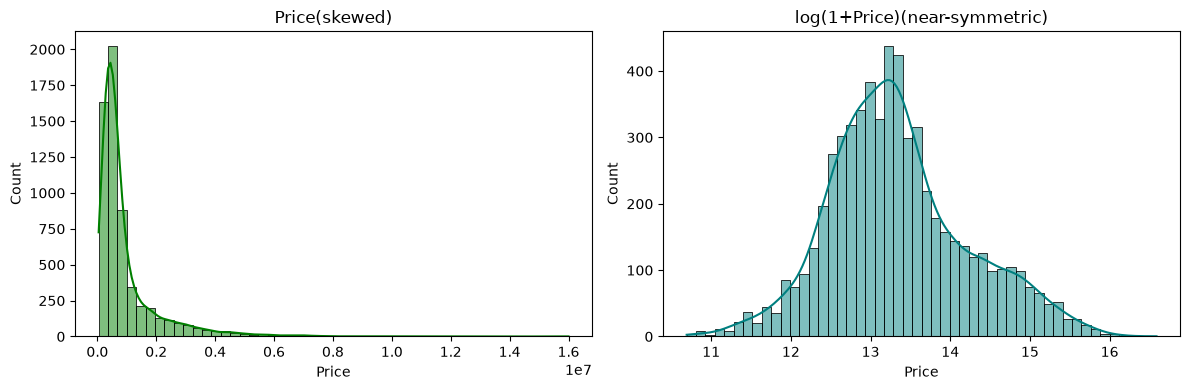

Skew raw: 3.34 | skew log: 0.42


In [24]:
fig, ax = plt.subplots(1,2,figsize = (12,4))
sns.histplot(df['Price'] , bins = 50,kde=True, color = 'green', ax = ax[0]);ax[0].set_title("Price(skewed)")
sns.histplot(np.log1p(df['Price']) , bins = 50, kde = True, color = 'teal', ax = ax[1]);ax[1].set_title("log(1+Price)(near-symmetric)")
plt.tight_layout(); plt.show()
print("Skew raw:", round(df["Price"].skew(), 2), "| skew log:", round(np.log1p(df["Price"]).skew(), 2))

#### 2. Price Vs Year - Scatter Plot

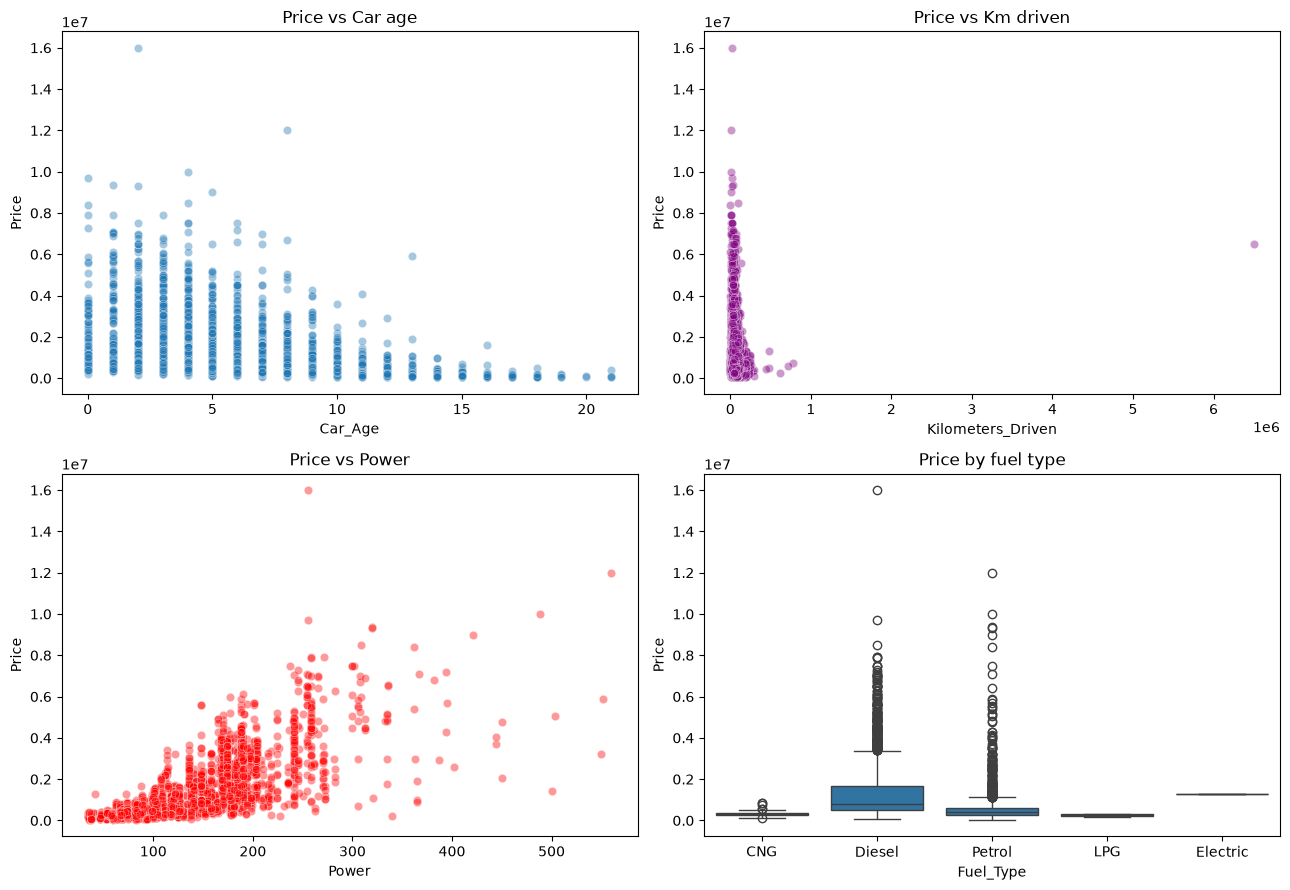

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
sns.scatterplot(data=df, x="Car_Age", y="Price", alpha=.4, ax=ax[0, 0]); ax[0, 0].set_title("Price vs Car age")
sns.scatterplot(data=df, x="Kilometers_Driven", y="Price", alpha=.4, color="purple", ax=ax[0, 1]); ax[0, 1].set_title("Price vs Km driven")
sns.scatterplot(data=df, x="Power", y="Price", alpha=.4, color="red", ax=ax[1, 0]); ax[1, 0].set_title("Price vs Power")
sns.boxplot(data=df, x="Fuel_Type", y="Price", ax=ax[1, 1]); ax[1, 1].set_title("Price by fuel type")
plt.tight_layout(); plt.show()

#### 3. Price Vs Km Driven - Scatter Plot

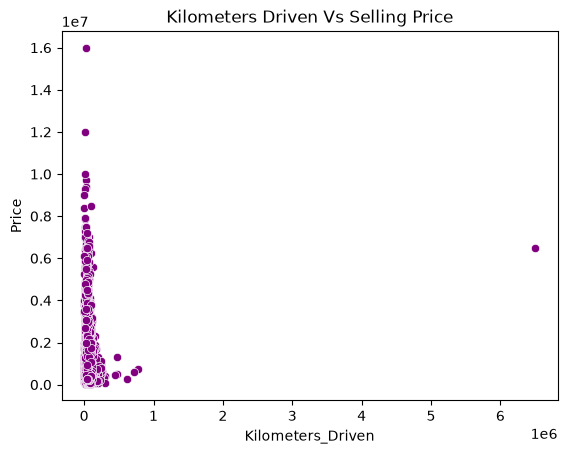

In [26]:
sns.scatterplot(data = df,x= 'Kilometers_Driven',y = 'Price', color = 'purple')
plt.title('Kilometers Driven Vs Selling Price')
plt.show()

In [27]:
df.loc[df['Kilometers_Driven'].nlargest(10).index,['Name','Year','Kilometers_Driven','Price']]

,Name,Year,Kilometers_Driven,Price
2328,BMW X5 xDrive 30d M Sport,2017,6500000,6500000
340,Skoda Octavia Ambition Plus 2.0 TDI AT,2013,775000,750000
1860,Volkswagen Vento Diesel Highline,2013,720000,590000
358,Hyundai i10 Magna 1.2,2009,620000,270000
2823,Volkswagen Jetta 2013-2015 2.0L TDI Highline AT,2015,480000,1300000
3092,Honda City i VTEC SV,2015,480000,500000
4491,Hyundai i20 Magna Optional 1.2,2013,445000,445000
3649,Tata Indigo LS,2008,300000,100000
1528,Toyota Innova 2.5 G (Diesel) 8 Seater BS IV,2005,299322,400000
1975,Skoda Superb 1.8 TSI MT,2012,282000,330000


In [28]:
df = df.drop(index = 2328)

#### 4. Kilometers Driven Vs Selling Price

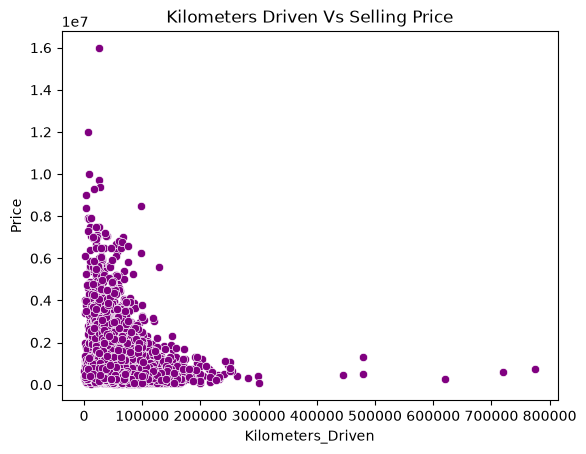

In [29]:
sns.scatterplot(data = df,x= 'Kilometers_Driven',y = 'Price', color = 'purple')
plt.title('Kilometers Driven Vs Selling Price')
plt.show()

#### 5. Price Vs Power - Scatter Plot

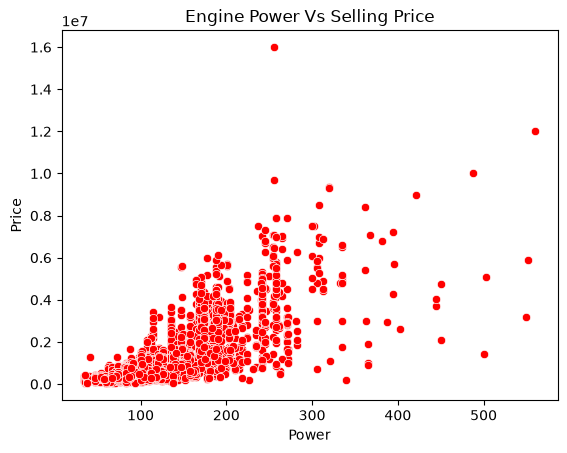

In [30]:
sns.scatterplot(data = df,x= 'Power',y = 'Price', color = 'red')
plt.title('Engine Power Vs Selling Price')
plt.show()

#### 6. Price By Fuel Type

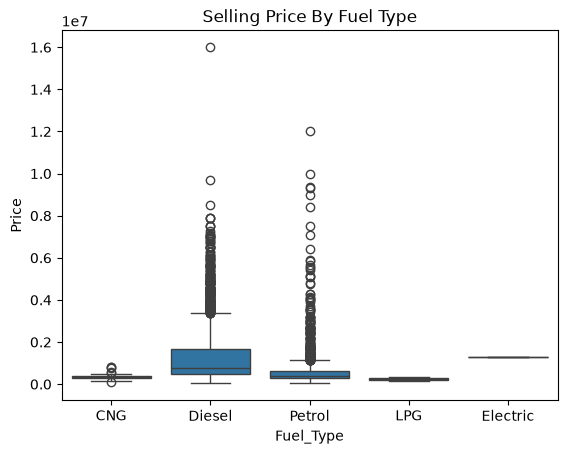

In [31]:
sns.boxplot(data = df, x = 'Fuel_Type', y = 'Price')
plt.title('Selling Price By Fuel Type')
plt.show()

#### 7. Price By Owner Type

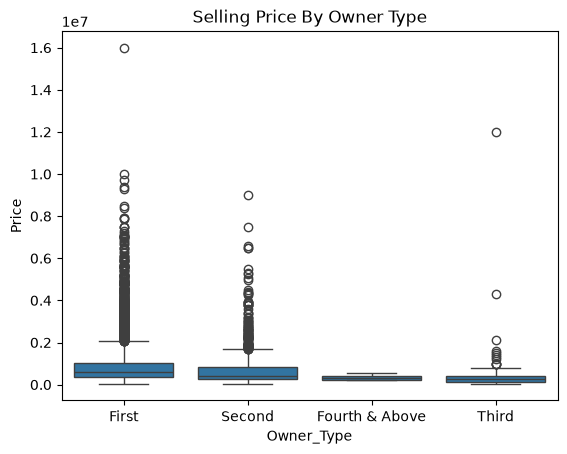

In [32]:
sns.boxplot(data = df, x = 'Owner_Type', y = 'Price')
plt.title('Selling Price By Owner Type')
plt.show()

#### 8. Price By Brand

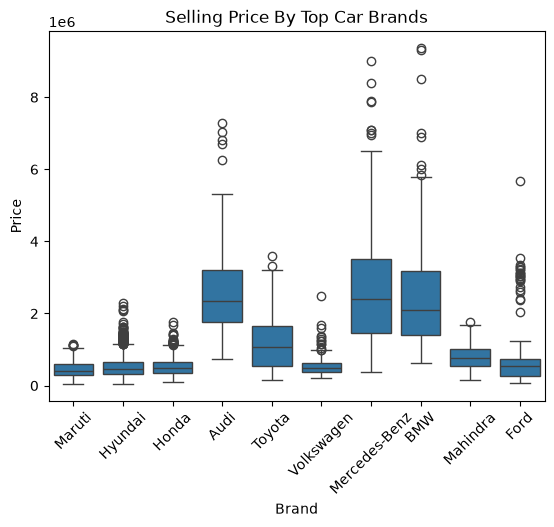

In [33]:
top_brands = df['Brand'].value_counts().head(10).index
sns.boxplot(data = df[df['Brand'].isin(top_brands)], x = 'Brand', y = 'Price')
plt.xticks(rotation = 45)
plt.title('Selling Price By Top Car Brands')
plt.show()

#### 9. New Car Model Price Vs Selling Price

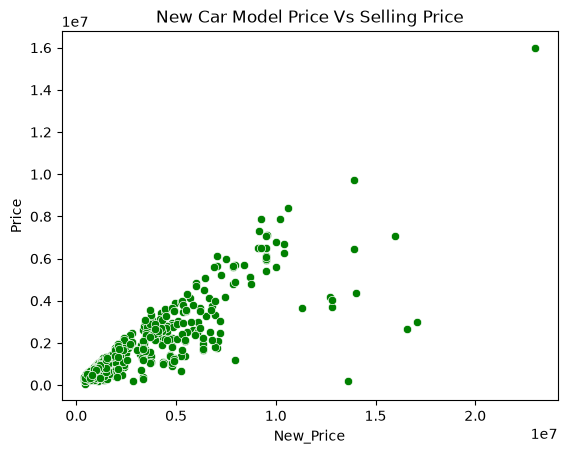

In [34]:
sns.scatterplot(data = df, x = "New_Price", y = "Price",color = 'green')
plt.title("New Car Model Price Vs Selling Price")
plt.show()

In [35]:
df.nlargest(10,'Price')[['Name','New_Price','Price']]

,Name,New_Price,Price
4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,23000000.0,16000000
5781,Lamborghini Gallardo Coupe,<NA>,12000000
5919,Jaguar F Type 5.0 V8 S,<NA>,10000000
1505,Land Rover Range Rover Sport SE,13900000.0,9707000
1974,BMW 7 Series 740Li,<NA>,9367000
1984,BMW 7 Series 740Li,<NA>,9300000
4691,Mercedes-Benz SLK-Class 55 AMG,<NA>,9000000
5535,BMW X6 xDrive 40d M Sport,<NA>,8500000
2095,Mercedes-Benz SLC 43 AMG,10600000.0,8396000
1885,Mercedes-Benz GLS 350d Grand Edition,10200000.0,7900000


#### 10. Correlation Heatmap

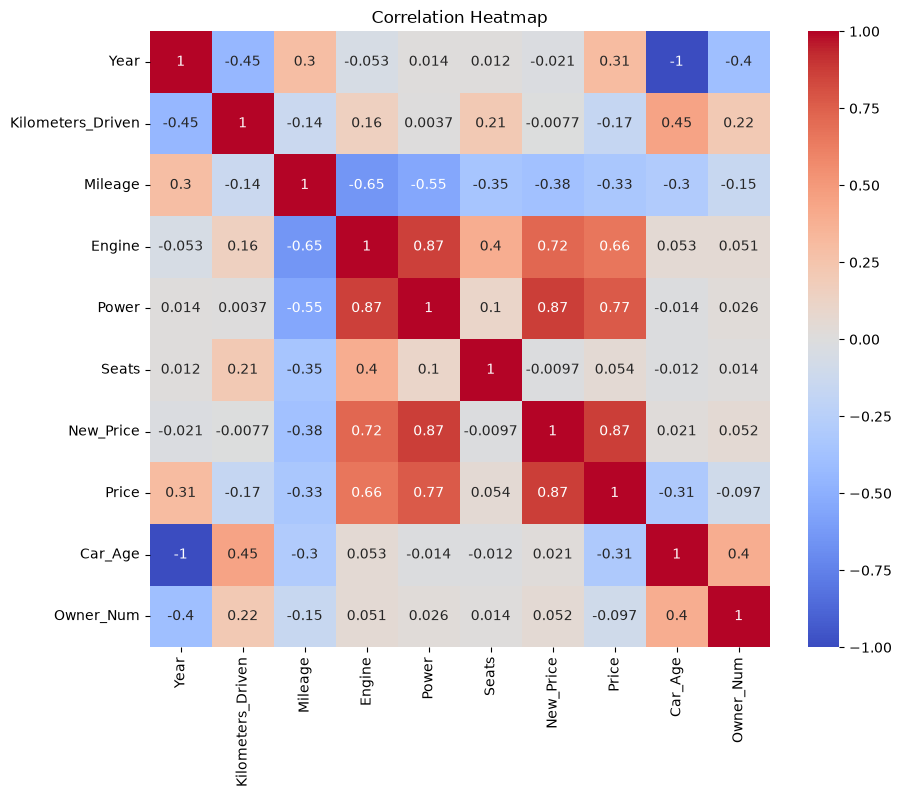

In [36]:
num_col = df.select_dtypes(include = 'number')
plt.figure(figsize = (10,8))
sns.heatmap(num_col.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Multicollinearity - VIF Analysis

In [37]:
for col in['Mileage','Engine','Power','Seats','Car_Age','Kilometers_Driven']:
    df[col] = df[col].fillna(df[col].median())

In [38]:
from statsmodels.tools.tools import add_constant
vif_columns =['Mileage','Engine','Power','Seats','Car_Age','Kilometers_Driven']
tmp = add_constant(df[vif_columns].fillna(df[vif_columns].median()))

vif_result=pd.Series([ variance_inflation_factor(tmp.values,i)
                    for i in range(1,tmp.shape[1])],index = vif_columns)
vif_result.round(2).sort_values(ascending = False) 

Engine               6.82
Power                5.58
Mileage              2.03
Seats                1.73
Car_Age              1.50
Kilometers_Driven    1.39
dtype: float64

# Machine Learning Model Building

### - Feature and Target selection

In [39]:
target = "Price"
X = df.drop(['Name','Owner_Type','New_Price','Price','Year'],axis = 1)
y = df[target]

In [40]:
X.head()

,Location,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,Seats,Car_Age,Brand,Model,Owner_Num
0,Mumbai,72000,CNG,Manual,26.60,998.0,58.16,5.0,9,Maruti,Wagon,1
1,Pune,41000,Diesel,Manual,19.67,1582.0,126.20,5.0,4,Hyundai,Creta,1
2,Chennai,46000,Petrol,Manual,18.20,1199.0,88.70,5.0,8,Honda,Jazz,1
3,Chennai,87000,Diesel,Manual,20.77,1248.0,88.76,7.0,7,Maruti,Ertiga,1
4,Coimbatore,40670,Diesel,Automatic,15.20,1968.0,140.80,5.0,6,Audi,A4,2


In [41]:
y.head()

0     175000
1    1250000
2     450000
3     600000
4    1773999
Name: Price, dtype: int64

In [42]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (6018, 12)
y shape: (6018,)


## Train-Test Split

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

X_train (4814, 12)
X_test (1204, 12)
y_train (4814,)
y_test (1204,)


#### Numerical and Categorical Features

In [44]:
print("Categorical Features:",X.select_dtypes(include= str).columns)
print("Numeric Features:",X.select_dtypes(include= np.number).columns)

Categorical Features: Index(['Location', 'Fuel_Type', 'Transmission', 'Brand', 'Model'], dtype='str')
Numeric Features: Index(['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age',
       'Owner_Num'],
      dtype='str')


#### Categorical Transformer - One Hot Encoder

In [45]:
cat_feature = X_train.select_dtypes(include = str).columns.tolist()
cat_transform = Pipeline(steps = [("imputer",SimpleImputer(strategy="most_frequent")),
                                  ("encoder",OneHotEncoder(handle_unknown = "ignore"))])

#### Numerical Transformer - Standard Scalar

In [46]:
num_feature = X_train.select_dtypes(include = np.number).columns.tolist()
num_transform = Pipeline(steps = [("imputer",SimpleImputer(strategy="median")),
                                  ("scaler",StandardScaler())])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_feature])
X_test_scaled = scaler.transform(X_test[num_feature])

## Column Transform

#### Linear Models 

In [47]:
from sklearn.compose import ColumnTransformer

In [48]:
preprocessor = ColumnTransformer(transformers = [
    ('num',num_transform,num_feature),
    ('cat',cat_transform,cat_feature)])

#### Tree Models

In [49]:
from sklearn.preprocessing import OrdinalEncoder
# tree models: no scaling needed, ordinal-encode categoricals
tree_pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_feature),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_feature)])


In [50]:
def log_target(reg):
    """Fit on log1p(price), predict back on the rupee scale (always positive)."""
    return TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)

## Machine Learning Models

In [51]:
results = []
def evaluate(name, y_true, y_pred, cv_r2=np.nan):
    row = {
        "Model": name,
        "Test R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Negative preds": int((y_pred < 0).sum()),
        "Min pred": y_pred.min(),
    }
    results.append(row)
    return row


#### Base Model

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [53]:
baseline_pred = np.repeat(y_train.mean(),len(y_test))  # Mean of y trainis repeated to the len of y test 
evaluate("Baseline Model(mean) ", y_test, baseline_pred)
pd.DataFrame(results).round(2)

,Model,Test R2,MAE,RMSE,Negative preds,Min pred
0,Baseline Model(mean),-0.0,690522.05,1043229.11,0,955204.57


#### Linear Regression Model

In [54]:
lin_raw = Pipeline([("prep", preprocessor), ("model", LinearRegression())]).fit(X_train, y_train)
y_pred = lin_raw.predict(X_test)
evaluate("Linear Regression (raw price)", y_test, y_pred)
print("Negative predictions:", (y_pred < 0).sum(), "of", len(y_pred), "| lowest:", round(y_pred.min()))
pd.DataFrame(results).round(2)

Negative predictions: 76 of 1204 | lowest: -828330


,Model,Test R2,MAE,RMSE,Negative preds,Min pred
0,Baseline Model(mean),-0.00,690522.05,1043229.11,0,955204.57
1,Linear Regression (raw price),0.83,242322.75,430282.70,76,-828329.68


#### Ridge + log target - The fix for negative predictions

In [55]:
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor

 Ridge Analysis - Raw Price

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)
ridge_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",Ridge(alpha=.5))])
ridge_model.fit(X_train,y_train)
y_pred_raw = ridge_model.predict(X_test)
print("R2_score:",r2_score(y_test, y_pred_raw))
print("Negative predictions:", (y_pred_raw < 0).sum(), "| lowest:", round(y_pred_raw.min()))

R2_score: 0.8296110282791995
Negative predictions: 79 | lowest: -836315


Ridge Analysis - With log target

In [57]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

ridge_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",log_target(Ridge(alpha=.5)))])
ridge_model.fit(X_train,y_train)
y_pred_log = ridge_model.predict(X_test)
print("Negative predictions:", (y_pred_log < 0).sum(), "| lowest:", round(y_pred_log.min()))
evaluate("Ridge + Log target", y_test, y_pred_log)
pd.DataFrame(results).round(2)

Negative predictions: 0 | lowest: 58154


,Model,Test R2,MAE,RMSE,Negative preds,Min pred
0,Baseline Model(mean),-0.00,690522.05,1043229.11,0,955204.57
1,Linear Regression (raw price),0.83,242322.75,430282.70,76,-828329.68
2,Ridge + Log target,0.91,130943.50,307986.13,0,58153.65


Validation

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)

from sklearn.model_selection import GridSearchCV

ridge_model_validated = Pipeline(steps = [("preprocessor",preprocessor),
                                    ("regressor",log_target(Ridge()))])
param_grid = {'regressor__regressor__alpha': np.logspace(-5,0,30)}
grid_search = GridSearchCV(estimator=ridge_model_validated,param_grid=param_grid,cv=5,scoring='r2')
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)
best_ridge = grid_search.best_estimator_
y_pred = best_ridge.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Best alpha: {'regressor__regressor__alpha': np.float64(1.0)}
Best CV R²: 0.8875494878969439
Test R²: 0.9044717203442358


Comparison of train and test values

In [60]:
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison['Actual'] = comparison['Actual'].round().astype(int)
comparison['Predicted'] = comparison['Predicted'].round().astype(int)
comparison.head(10)

,Actual,Predicted
1463,150000,113283
181,145000,146783
2507,220000,210172
3375,434999,474910
5816,300000,326280
2036,944999,853052
2974,615000,568822
960,260000,268316
318,1060000,1164507
2628,340000,425177


#### Lasso Regression

In [61]:
from sklearn.linear_model import Lasso

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 10)
lasso_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",log_target(Lasso(alpha=0.0002)))])
lasso_model.fit(X_train,y_train)
y_pred = lasso_model.predict(X_test)
evaluate("Lasso + Log target", y_test, y_pred)
pd.DataFrame(results).round(2)

,Model,Test R2,MAE,RMSE,Negative preds,Min pred
0,Baseline Model(mean),-0.00,690522.05,1043229.11,0,955204.57
1,Linear Regression (raw price),0.83,242322.75,430282.70,76,-828329.68
2,Ridge + Log target,0.91,130943.50,307986.13,0,58153.65
3,Lasso + Log target,0.89,146956.96,350198.62,0,58969.59


Fine tuning the Lasso model

In [63]:
for i in range (20,30):
    lasso_model = Pipeline(steps = [("preprocessor",preprocessor),
                                ("regressor",log_target(Lasso(alpha=i/100000)))])
    lasso_model.fit(X_train,y_train)
    y_pred = lasso_model.predict(X_test)
    lasso_pca_r2 = r2_score(y_test,y_pred)
    print(f"Lasso r2 for alpha {i/100000}:,{lasso_pca_r2}")

Lasso r2 for alpha 0.0002:,0.8871407606104081
Lasso r2 for alpha 0.00021:,0.8860062313323058
Lasso r2 for alpha 0.00022:,0.8849247326021417
Lasso r2 for alpha 0.00023:,0.8839057749461915
Lasso r2 for alpha 0.00024:,0.8829407615947075
Lasso r2 for alpha 0.00025:,0.8819523785752178
Lasso r2 for alpha 0.00026:,0.8810222527459448
Lasso r2 for alpha 0.00027:,0.8800509038267821
Lasso r2 for alpha 0.00028:,0.8791363817645609
Lasso r2 for alpha 0.00029:,0.8783319300197726


Validation

In [64]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", log_target(Lasso(max_iter = 10000)))])
param_grid = {'regressor__regressor__alpha': np.logspace(-5,0,30)}
grid_search = GridSearchCV( estimator=lasso_model, param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)
best_lasso = grid_search.best_estimator_
y_pred = best_lasso.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Best alpha: {'regressor__regressor__alpha': np.float64(7.278953843983146e-05)}
Best CV R²: 0.8846937256647189
Test R²: 0.9046401325742749


#### Polynomial Regression

In [65]:
from sklearn.preprocessing import PolynomialFeatures

In [66]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler1", StandardScaler()),
                      ("poly", PolynomialFeatures(degree=2, include_bias=False)), ("scaler2", StandardScaler())]), num_feature),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore"))]), cat_feature),
])
gs = GridSearchCV(Pipeline([("prep", preprocessor), ("regressor", log_target(Ridge()))]),
                  {"regressor__regressor__alpha": np.logspace(-1, 3, 9)}, cv=5, scoring="r2", n_jobs=-1).fit(X_train, y_train)
poly_ridge = gs.best_estimator_
y_pred_poly = poly_ridge.predict(X_test)

evaluate("PolynomialRegressor + Log target", y_test, y_pred_poly)
print("Best params:", gs.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best params: {'regressor__regressor__alpha': np.float64(0.1)}
Best CV R²: 0.8846937256647189


#### Random forest + Log target

In [67]:
from sklearn.ensemble import RandomForestRegressor

gs = GridSearchCV(Pipeline([("prep", tree_pre), ("regressor", log_target(RandomForestRegressor(random_state=1, n_jobs=-1)))]),
                  {"regressor__regressor__n_estimators": [200], "regressor__regressor__max_features": [0.5], "regressor__regressor__min_samples_leaf": [1, 2]},
                  cv=5, scoring="r2", n_jobs=1).fit(X_train, y_train)
rf = gs.best_estimator_
y_pred = rf.predict(X_test)
print("Best params:", gs.best_params_)
print("Random Forest best score", gs.best_score_)
evaluate("Random Forest + Log target", y_test, y_pred)


Best params: {'regressor__regressor__max_features': 0.5, 'regressor__regressor__min_samples_leaf': 2, 'regressor__regressor__n_estimators': 200}
Random Forest best score 0.850499448380585


{'Model': 'Random Forest + Log target',
 'Test R2': 0.9191655433804434,
 'MAE': 136204.90395469198,
 'RMSE': np.float64(296376.7492860978),
 'Negative preds': 0,
 'Min pred': np.float64(71033.12896125161)}

#### Gradient Boosting

In [68]:
from sklearn.ensemble import HistGradientBoostingRegressor
gs = GridSearchCV(Pipeline([("prep", tree_pre), ("regressor", log_target(HistGradientBoostingRegressor(random_state=1)))]),
                  {"regressor__regressor__learning_rate": [0.05, 0.1],
                   "regressor__regressor__max_iter": [400],
                   "regressor__regressor__max_leaf_nodes": [15, 31]},
                  cv=5, scoring="r2", n_jobs=-1).fit(X_train, y_train)
gb = gs.best_estimator_
y_pred = gb.predict(X_test)
print("Best params:", gs.best_params_)
print("Best Score:", gs.best_score_)
evaluate("Gradient Boosting + Log target", y_test, y_pred)

Best params: {'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_iter': 400, 'regressor__regressor__max_leaf_nodes': 15}
Best Score: 0.8903527223642647


{'Model': 'Gradient Boosting + Log target',
 'Test R2': 0.9038169947810828,
 'MAE': 120729.89893440907,
 'RMSE': np.float64(323292.0609844358),
 'Negative preds': 0,
 'Min pred': np.float64(66021.56937162938)}

#### Best Model

In [69]:
comparison = pd.DataFrame(results).round(2).set_index("Model").sort_values("Test R2", ascending=False)
comparison

,Test R2,MAE,RMSE,Negative preds,Min pred
Model,,,,,
PolynomialRegressor + Log target,0.94,116296.02,262163.17,0,59818.33
Random Forest + Log target,0.92,136204.90,296376.75,0,71033.13
Ridge + Log target,0.91,130943.50,307986.13,0,58153.65
Gradient Boosting + Log target,0.90,120729.90,323292.06,0,66021.57
Lasso + Log target,0.89,146956.96,350198.62,0,58969.59
Linear Regression (raw price),0.83,242322.75,430282.70,76,-828329.68
Baseline Model(mean),-0.00,690522.05,1043229.11,0,955204.57


best_model = poly_ridge

## Save model and predict car price

In [70]:
import joblib
joblib.dump(poly_ridge, "used_car_price_model.pkl")

['used_car_price_model.pkl']

In [71]:
model = joblib.load("used_car_price_model.pkl")
new_sample_cars = pd.DataFrame({
                                "Location": ["Kochi","Pune", "Delhi","Mumbai"],
                                "Kilometers_Driven": [41000,30000,48000,34000],
                                "Fuel_Type": ["Petrol","Petrol","Diesel","Petrol"], 
                                "Transmission": ["Manual","Automatic","Automatic","Manual"],
                                "Mileage": [16.67,18.5,13.5,23], 
                                "Engine": [1198,2179,1984,1995], 
                                "Power": [98,115,167, 88],
                                "Seats": [5,5,5,5],
                                "Car_Age": [4,2,3,4],
                                "Brand": ["Honda","Land Rover","Jeep","Nissan"], 
                                "Model": ["Amaze","Rover","Compass","Micra"],
                                "Owner_Num": [2,1,1,1]})


car_names = ["Car 1", "Car 2", "Car 3" ,"Car 4"]

print("New sample cars created.")
new_sample_cars

New sample cars created.


,Location,Kilometers_Driven,Fuel_Type,Transmission,Mileage,Engine,Power,Seats,Car_Age,Brand,Model,Owner_Num
0,Kochi,41000,Petrol,Manual,16.67,1198,98,5,4,Honda,Amaze,2
1,Pune,30000,Petrol,Automatic,18.50,2179,115,5,2,Land Rover,Rover,1
2,Delhi,48000,Diesel,Automatic,13.50,1984,167,5,3,Jeep,Compass,1
3,Mumbai,34000,Petrol,Manual,23.00,1995,88,5,4,Nissan,Micra,1


In [72]:
# Car price prediction Results

#sample_scaled   = scaler.transform(sample_applicants)
predictions = []
predictions = model.predict(new_sample_cars).round()
#predictions = prediction.append
#probabilities   = model.predict_proba(new_sample_cars)

#prob_approved   = [f"{p[1]*100:.1f}%" for p in probabilities]
#prob_rejected   = [f"{p[0]*100:.1f}%" for p in probabilities]
#decision        = ["APPROVED" if p == 1 else "REJECTED" for p in predictions]

results_df = pd.DataFrame({
    "Car_Name"         : car_names,
    "Location"         : new_sample_cars["Location"].values,
    "Kilometers_Driven": new_sample_cars["Kilometers_Driven"].values,
    "Fuel_Type"        : new_sample_cars["Fuel_Type"].values,
    "Car_Age"	       : new_sample_cars["Car_Age"].values,
    "Brand"	           : new_sample_cars["Brand"].values,
    "Model"	           : new_sample_cars["Model"].values,
    "Car_Price"        : predictions
})

results_df.set_index("Car_Name", inplace=True)
results_df


#print(f"Predicted price: Rs {model.predict(new_car)[0]:,.0f}")



,Location,Kilometers_Driven,Fuel_Type,Car_Age,Brand,Model,Car_Price
Car_Name,,,,,,,
Car 1,Kochi,41000,Petrol,4,Honda,Amaze,456581.0
Car 2,Pune,30000,Petrol,2,Land Rover,Rover,3769552.0
Car 3,Delhi,48000,Diesel,3,Jeep,Compass,1511976.0
Car 4,Mumbai,34000,Petrol,4,Nissan,Micra,377086.0


In [73]:
print("Honda Amaze")
peers = df[(df.Brand == "Honda") & (df.Model == "Amaze") & df.Year.between(2015, 2017)]["Price"]
print(f"Sanity check - {len(peers)} comparable Honda Amaze (2015-17) listings: "
      f"median Rs {peers.median():,.0f}, range Rs {peers.min():,.0f} - {peers.max():,.0f}")

print("Land Rover")
peers = df[(df.Brand == "Land Rover") & (df.Model == "Rover") & df.Year.between(2016, 2019)]["Price"]
print(f"Sanity check - {len(peers)} comparable Land Rover (2015-17) listings: "
      f"median Rs {peers.median():,.0f}, range Rs {peers.min():,.0f} - {peers.max():,.0f}")

print("Jeep Compass")
peers = df[(df.Brand == "Jeep") & (df.Model == "Compass") & df.Year.between(2015, 2017)]["Price"]
print(f"Sanity check - {len(peers)} comparable Jeep Compass (2014-15) listings: "
      f"median Rs {peers.median():,.0f}, range Rs {peers.min():,.0f} - {peers.max():,.0f}")

print("Nissan Micra")
peers = df[(df.Brand == "Nissan") & (df.Model == "Micra") & df.Year.between(2015, 2017)]["Price"]
print(f"Sanity check - {len(peers)} comparable Nissan Micra (2013-15) listings: "
      f"median Rs {peers.median():,.0f}, range Rs {peers.min():,.0f} - {peers.max():,.0f}")

Honda Amaze
Sanity check - 44 comparable Honda Amaze (2015-17) listings: median Rs 532,500, range Rs 350,000 - 750,000
Land Rover
Sanity check - 21 comparable Land Rover (2015-17) listings: median Rs 4,476,000, range Rs 3,408,000 - 16,000,000
Jeep Compass
Sanity check - 7 comparable Jeep Compass (2014-15) listings: median Rs 1,750,000, range Rs 1,500,000 - 2,000,000
Nissan Micra
Sanity check - 7 comparable Nissan Micra (2013-15) listings: median Rs 426,000, range Rs 300,000 - 655,000


## Summary

- **Objective:** Predict used-car resale prices in India from 6,018 cleaned listings (2019-era prices), using age, kilometres, engine, power, mileage, seats, owner type, fuel, transmission, location, brand and model.
- **Data preparation:**
  - Removed duplicates and one impossible mileage entry (6.5 million km).
  - Treated zero values in Mileage and Seats as missing.
  - Parsed brand and model from the car name.
  - Engineered Car_Age, Log_Km and ordinal Owner type.
  - Split the data 80/20 (4,814 train / 1,204 test) before any fitting, so imputation, scaling and encoding use training rows only.
- **Key finding:** Price is right-skewed and multiplicative. A plain linear model on raw price gave 69 impossible negative predictions (as low as Rs -1.02M), so all final models use a log(1+price) target.
- **Models compared:** Mean baseline, Linear (raw and log), Ridge, Lasso, Polynomial + Ridge, Random Forest and Gradient Boosting. All were tuned with 5-fold CV on training data only.
- **Selected model:** Ridge + log target, chosen by CV (log R² = 0.951 ± 0.006).
- **Test performance:**
  - Log R² is 0.951 and rupee R² is 0.890.
  - Median error is 10.3%, mean error 14.1%.
  - MAE is Rs 138,517, which is 80% lower than the mean-price baseline (Rs 704,849).
  - 48% of predictions fall within ±10% of the true price, 78% within ±20% and 91% within ±30%.
  - Errors are unbiased (median signed error +0.1%).
- **Key drivers:** Brand and model matter most (premiums for Porsche, Land Rover, Mercedes-Benz, BMW; discounts for Datsun, Tata, Chevrolet, Fiat). Price falls with age and kilometres and rises with power and engine size.
- **Model ranking caveat:** Five models are within one CV standard deviation of each other. Polynomial + Ridge is a reasonable alternative if expensive cars matter more (rupee R² 0.916 vs 0.890).
- **Weak spots:**
  - The cheapest quartile has the highest percentage error (13.1% median; only 67% within ±20%).
  - The priciest quartile has the largest rupee error (MAE Rs 376,968).
  - The biggest misses are older premium sedans and SUVs (Camry, Octavia, Superb), which the model over-prices, and one Fortuner that may be a data-entry error.
- **Limitations:**
  - One random split, and near-identical listings can appear in both train and test.
  - `New_Price` (~86% missing) was not used.
  - Missing values are filled with global medians.
  - The data is from 2019, so the model needs retraining before use on current prices.
- **Next steps:**
  - Grouped CV by Brand+Model, or a time-based split.
  - Brand × Age interactions and target encoding for `Model`.
  - Model-specific imputation of Power and Engine.
  - Prediction intervals, for example "Rs 4.7 lakh, likely 3.8 to 5.7".
  - Drift monitoring with scheduled retraining.